In [ ]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import random
from scipy.stats import binom, uniform, norm
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = sns.load_dataset('taxis')

# 통계량 확인하기
* 평균, 중앙값, 최빈값 구하기


In [3]:
mean_val = data['total'].mean()
median_val = data['total'].median()

# 최빈값을 구하기 위해 구간별로 데이터 나누고 범주형 데이터로 변환하기
binned_total = pd.cut(data['total'], bins=100, right=False)
modal_interval = binned_total.mode()[0]
mode_val = modal_interval.mid

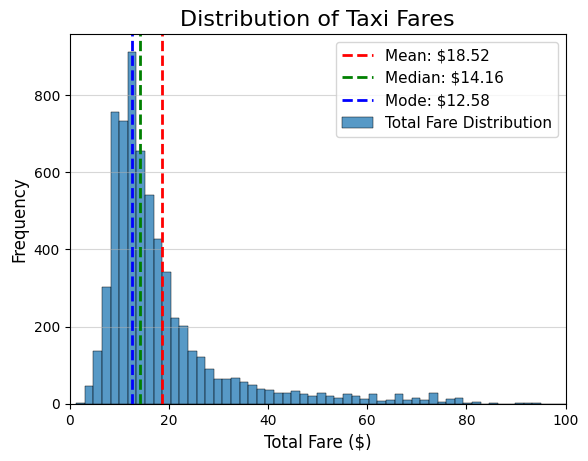

In [4]:
plt.figure()

sns.histplot(data['total'], bins=100, label='Total Fare Distribution')
plt.xlim(0,100)

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_val:.2f}')
plt.axvline(mode_val, color='blue', linestyle='--', linewidth=2, label=f'Mode: ${mode_val:.2f}')

plt.title('Distribution of Taxi Fares', fontsize=16)
plt.xlabel('Total Fare ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.5)

plt.show()


왜도: 데이터 분포의 비대칭성을 나타내는 지표  
첨도: 분포의 뾰족한 정도와 꼬리의 두께를 나타내는 지표

In [5]:
skewness = data['total'].skew()
kurtosis = data['total'].kurt()

print(f"왜도 (Skewness): {skewness:.4f}")
print(f"첨도 (Kurtosis): {kurtosis:.4f}")

왜도 (Skewness): 3.0933
첨도 (Kurtosis): 15.0657


# 분산과 표준편차, 표준오차

In [6]:
variance = data['total'].var()
std_dev = data['total'].std()

# 표준오차 계산 (Standard Error of the Mean)
# 표준오차는 표본 표준편차를 표본 크기의 제곱근으로 나눈 값입니다.
std_error = std_dev / np.sqrt(len(data['total']))

print(f"분산 (Variance): {variance:.2f}")
print(f"표준편차 (Standard Deviation): {std_dev:.2f}")
print(f"표준오차 (Standard Error): {std_error:.2f}")

분산 (Variance): 190.87
표준편차 (Standard Deviation): 13.82
표준오차 (Standard Error): 0.17


# 데이터의 분포 확인하기
* 상자수염그림
* 바이올린 플롯
* 스웜 플롯

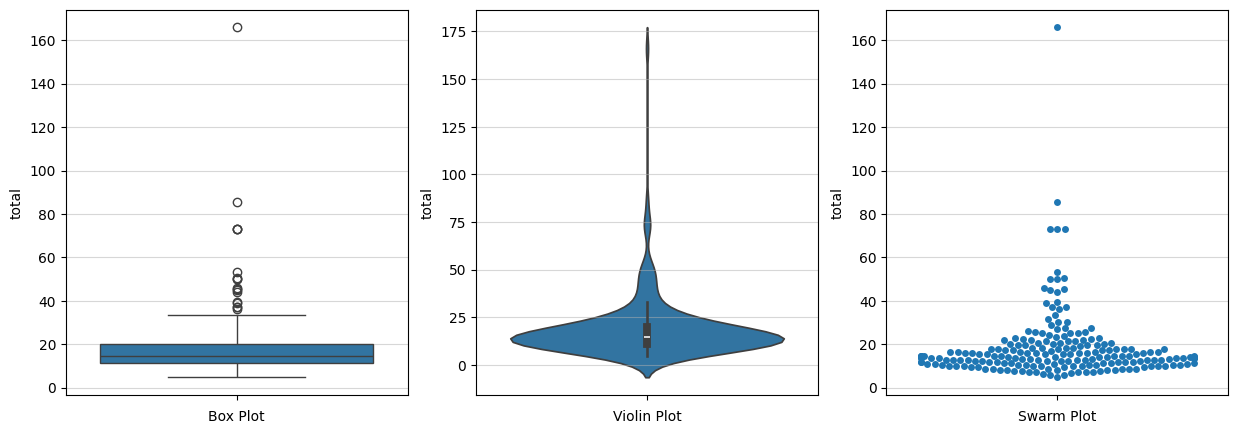

In [7]:
taxis_sample = data['total'].sample(n=200, random_state=42)
plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)

# 상자수염그림
sns.boxplot(taxis_sample)

plt.xlabel('Box Plot')
plt.ylabel('total')
plt.grid(axis='y', alpha=0.5)

plt.subplot(1, 3, 2)

# 바이올린 플롯
sns.violinplot(taxis_sample)

plt.xlabel('Violin Plot')
plt.ylabel('total')
plt.grid(axis='y', alpha=0.5)

plt.subplot(1, 3, 3)

# 스웜 플롯
sns.swarmplot(taxis_sample)

plt.xlabel('Swarm Plot')
plt.ylabel('total')
plt.grid(axis='y', alpha=0.5)

plt.show()

# 큰 수의 법칙과 중심극한정리

**큰 수의 법칙(Law of Large Numbers)**
* 표본의 크기가 커질수록 그 표본의 평균이 모평균(기댓값)에 가까워진다는 원리

In [8]:
def coin_flip_simulation(num_flips):
    heads_count = 0
    probabilities = []

    # num_flips 만큼 0(뒷면) 또는 1(앞면)을 무작위로 생성
    for i in range(1, num_flips+1):
        if random.randint(0, 1) == 1:
            heads_count += 1

        # 현재까지 총 던진 횟수 대비 앞면이 나온 횟수의 비율을 계산하여 저장
        current_probability = heads_count / i
        probabilities.append(current_probability)

    return probabilities

In [9]:
# 동전 던지기 횟수 설정
total_flips = 1000 # 숫자를 늘릴 수록 그래프가 기대값에 수렴합니다.

results = coin_flip_simulation(total_flips)

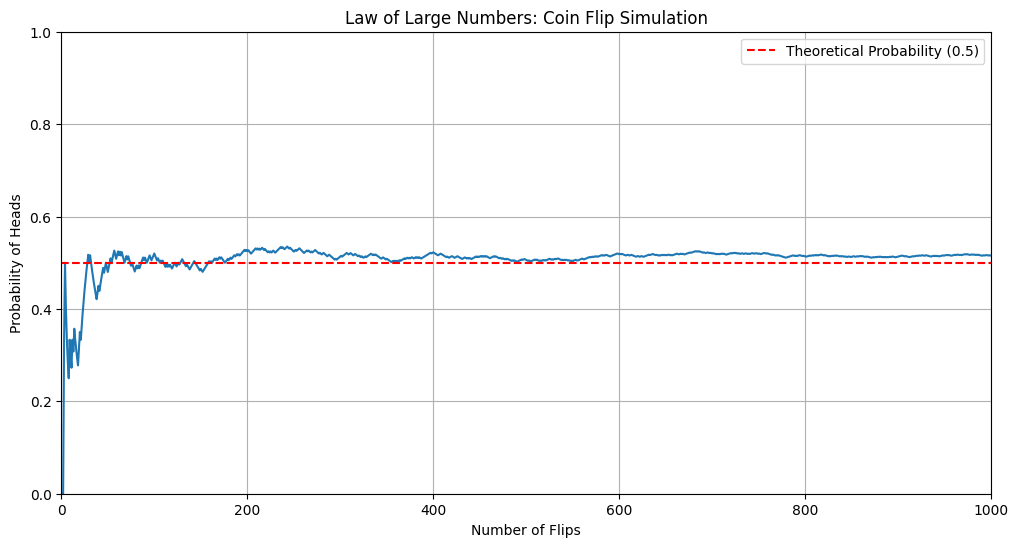

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(range(1, total_flips +1), results)
plt.axhline(y=0.5, color='r', linestyle='--', label='Theoretical Probability (0.5)')

plt.title('Law of Large Numbers: Coin Flip Simulation')
plt.xlabel('Number of Flips')
plt.ylabel('Probability of Heads')
plt.legend()
plt.grid(True)

plt.xlim(0, total_flips)
plt.ylim(0, 1)

plt.show()

**중심극한정리(Central Limit Theorem, CLT)**
* 모집단의 분포와 상관 없이, 표본의 크기가 충분히 크다면 표본 평균의 분포는 정규분포에 가까워짐

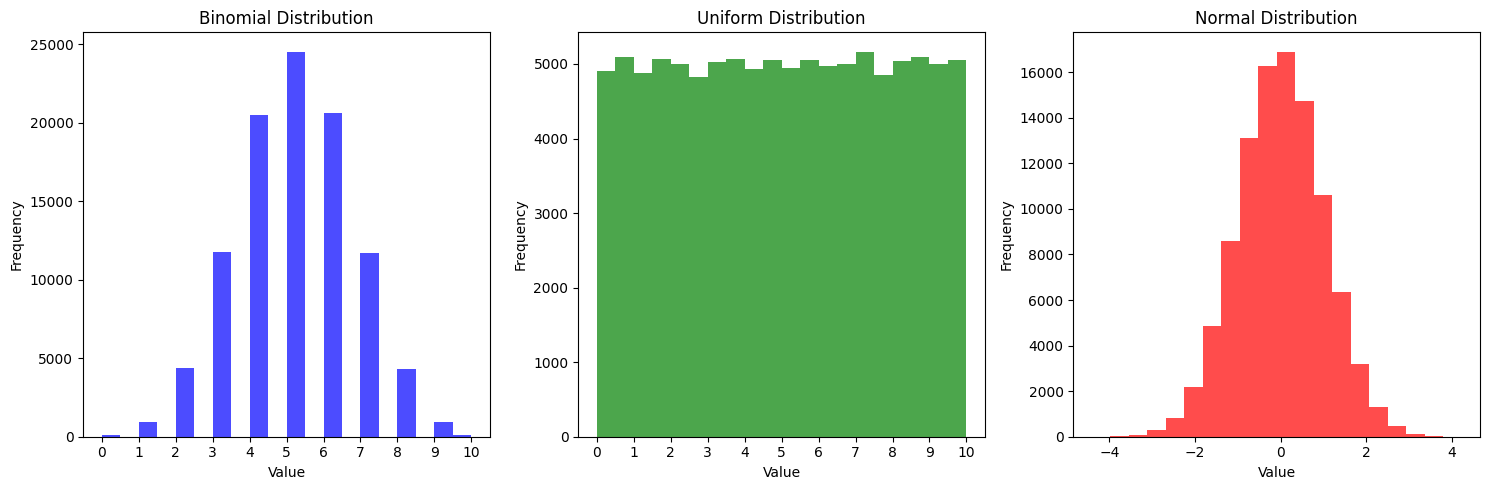

In [11]:
# 모집단 생성
np.random.seed(42)

sample_size = 100000
# 이항 분포 샘플
binomial_data = binom.rvs(n=10, p=0.5, size=sample_size)
# 균등 분포 샘플
uniform_data = uniform.rvs(loc=0, scale=10, size=sample_size)
# 정규 분포 샘플
normal_data = norm.rvs(loc=0, scale=1, size=sample_size)

#시각화
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(binomial_data, bins=20, color="blue", alpha=0.7)
plt.title("Binomial Distribution")
plt.xlabel("Value")
plt.xticks(range(0,11))
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(uniform_data, bins=20, color="green", alpha=0.7)
plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.xticks(range(0,11))

plt.subplot(1, 3, 3)
plt.hist(normal_data, bins=20, color="red", alpha=0.7)
plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
# 표본 추출 횟수
num_samples = 500
sample_means = {
    "Binomial": [],
    "Uniform": [],
    "Normal": []
}

# 표본크기
sample_size = 50
#numpy.choice을 통해 샘플의 평균을 구하여 sample_means 딕셔너리 자료형에 각각 저장
for _ in range(num_samples):
    sample_means["Binomial"].append(np.mean(np.random.choice(binomial_data, size=sample_size)))
    sample_means["Uniform"].append(np.mean(np.random.choice(uniform_data, size=sample_size)))
    sample_means["Normal"].append(np.mean(np.random.choice(normal_data, size=sample_size)))

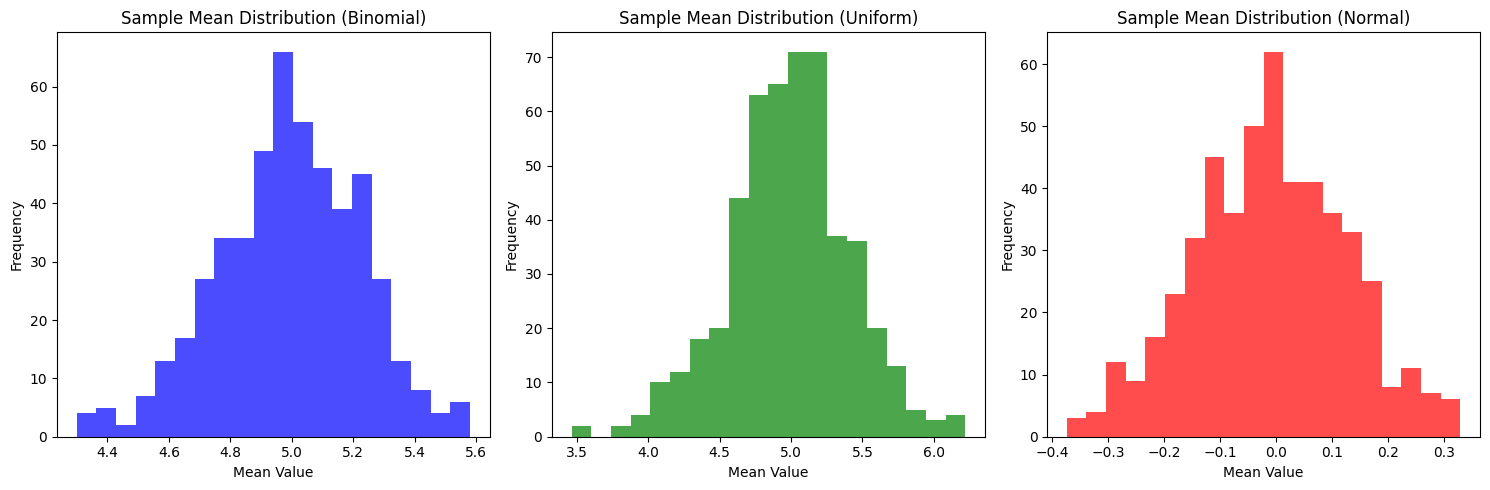

In [13]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(sample_means["Binomial"], bins=20, color="blue", alpha=0.7)
plt.title("Sample Mean Distribution (Binomial)")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(sample_means["Uniform"], bins=20, color="green", alpha=0.7)
plt.title("Sample Mean Distribution (Uniform)")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(sample_means["Normal"], bins=20, color="red", alpha=0.7)
plt.title("Sample Mean Distribution (Normal)")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 정규분포

- 평균 50, 표준편차 10인 정규분포에서 1,000개의 데이터를 생성하고 히스토그램 그리기

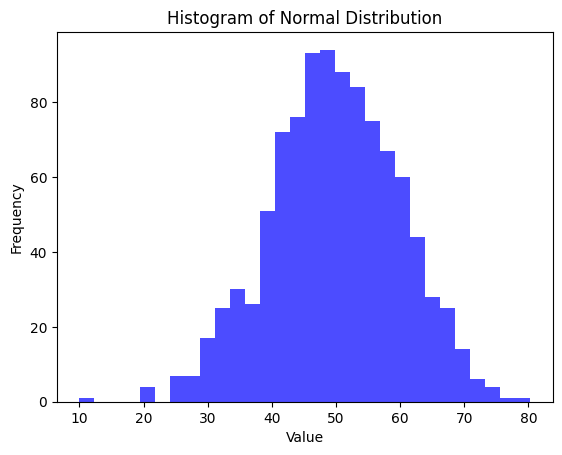

In [14]:
import matplotlib.pyplot as plt

# 정규분포 데이터 생성
data = np.random.normal(loc=50, scale=10, size=1000)

# 히스토그램 그리기
plt.hist(data, bins=30, color='blue', alpha=0.7)
plt.title("Histogram of Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# 신뢰구간 구하기

In [15]:
# 모집단 생성
# 평균 175, 표준편차10인 정규분포를 따르는 10만 명의 키 데이터 생성
population_mean = 175
population_std = 10
population = norm.rvs(loc=population_mean, scale=population_std, size=100000)

In [16]:
# 표본 추출
sample_size = 100
sample = np.random.choice(population, size=sample_size)

In [17]:
# 표본 통계량 계산
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1) # ddof = 자유도(Degrees of Freedom) 의미

print(f'표본 평균: {sample_mean}')
print(f'표본 표준 편차: {sample_std}')

표본 평균: 174.68038814135983
표본 표준 편차: 9.849531004398031


In [18]:
# 신뢰구간 계산
confidence_level = 0.95

n = len(sample)
dof = n - 1

# 신뢰수준에 따른 임계값 찾기
t_value = stats.t.ppf((1 + confidence_level) / 2, df=dof)

# 표준 오차 계산
std_error = sample_std / np.sqrt(n)

# 오차 범위
margin_of_error = t_value * std_error

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

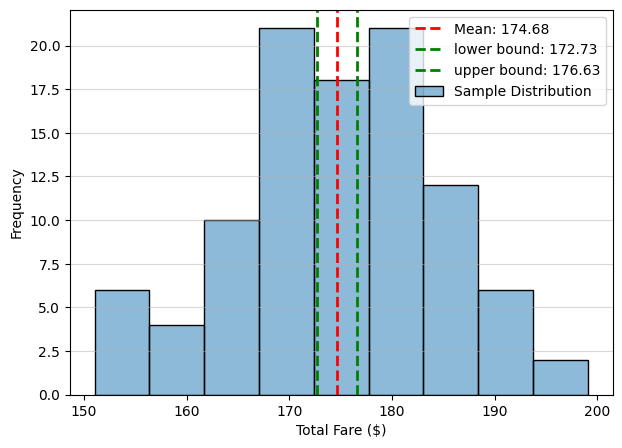

In [19]:
plt.figure(figsize=(7, 5))

sns.histplot(sample, alpha=0.5, label='Sample Distribution')

plt.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {sample_mean:.2f}')
plt.axvline(lower_bound, color='green', linestyle='--', linewidth=2, label=f'lower bound: {lower_bound:.2f}')
plt.axvline(upper_bound, color='green', linestyle='--', linewidth=2, label=f'upper bound: {upper_bound:.2f}')

plt.xlabel('Total Fare ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.show()

In [20]:
print("--- 표본 데이터 분석 결과 ---")
print(f"표본 크기: {n}")
print(f"표본 평균: {sample_mean:.2f}")
print(f"표본 표준편차: {sample_std:.2f}\n")
print(f"추정된 95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}]")

print("--- 95% 신뢰구간 추정 결과 ---")
print(f"실제 모평균 (우리가 모른다고 가정한 값): {population_mean}")

# 신뢰구간이 실제 모평균을 포함하는지 확인
if lower_bound <= population_mean <= upper_bound:
    print("\n🎉 추정 성공! 신뢰구간이 실제 모평균을 포함했습니다.")
else:
    print("\n😥 추정 실패! 신뢰구간이 실제 모평균을 포함하지 못했습니다.")

--- 표본 데이터 분석 결과 ---
표본 크기: 100
표본 평균: 174.68
표본 표준편차: 9.85

추정된 95% 신뢰구간: [172.73, 176.63]
--- 95% 신뢰구간 추정 결과 ---
실제 모평균 (우리가 모른다고 가정한 값): 175

🎉 추정 성공! 신뢰구간이 실제 모평균을 포함했습니다.


# 부트스트랩

In [21]:
# 모집단 생성
# 평균 175, 표준편차10인 정규분포를 따르는 10만 명의 키 데이터 생성
population_mean = 175
population_std = 10
population = norm.rvs(loc=population_mean, scale=population_std, size=100000)

In [22]:
# 표본 추출
sample_size = 100
sample = np.random.choice(population, size=sample_size)

In [23]:
# 부트스트랩 과정
n_bootstrap = 10000
bootstrap_means = []

np.random.seed(42)
for _ in range(n_bootstrap):
    bootstrap_sample = np.random.choice(
        sample,
        size=sample_size,
        replace = True
    )
    bootstrap_mean = np.mean(bootstrap_sample)
    bootstrap_means.append(bootstrap_mean)

In [24]:
# 부트스트래핑으로 신뢰구간 구하기
confidence_level = 0.95
lower_bound = np.percentile(bootstrap_means, (1 - confidence_level) / 2 * 100)
upper_bound = np.percentile(bootstrap_means, (1 + confidence_level) / 2 * 100)

In [25]:
print(f"--- 원본 표본 데이터 ---")
print(f"표본 크기: {len(sample)}")
print(f"표본 평균: {np.mean(sample):.2f}")
print(f"추정된 95% 신뢰구간: [{lower_bound:.2f}, {upper_bound:.2f}]\n")

print(f"--- 부트스트랩 95% 신뢰구간 추정 결과 ---")
print(f"실제 모평균 (우리가 모른다고 가정한 값): {population_mean}")


# 신뢰구간이 실제 모평균을 포함하는지 확인
if lower_bound <= population_mean <= upper_bound:
    print("\n🎉 추정 성공! 신뢰구간이 실제 모평균을 포함했습니다.")
else:
    print("\n😥 추정 실패! 신뢰구간이 실제 모평균을 포함하지 못했습니다.")

--- 원본 표본 데이터 ---
표본 크기: 100
표본 평균: 172.94
추정된 95% 신뢰구간: [171.16, 174.74]

--- 부트스트랩 95% 신뢰구간 추정 결과 ---
실제 모평균 (우리가 모른다고 가정한 값): 175

😥 추정 실패! 신뢰구간이 실제 모평균을 포함하지 못했습니다.


# numpy 기술통계와 소수점 표현



- 내장함수 help()와 dir()를 이용하거나 docs를 이용해서 다음 기술통계를 소수점 셋째자리까지 작성하기.
- 소수점자리는 f-string 문법을 이용해 표기하기 (참고:[f-string](https://blockdmask.tistory.com/429))
- 평균(_mean), 중앙값(_median), 분산(_var), 표준편차(_std) (참고 [numpy docs - mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) )

In [26]:
import numpy as np
data = [10, 20, 20, 30, 40]

In [27]:
_mean = np.mean(data)
_median = np.median(data)
_var = np.var(data)
_std = np.std(data)

print(f'평균은 {_mean:.3f}')
print(f'중앙값은 {_median:.3f}')
print(f'분산은 {_var:.3f}')
print(f'표준편차는 {_std:.3f}')

평균은 24.000
중앙값은 20.000
분산은 104.000
표준편차는 10.198


# 이상값과 분산 비교
- 시험 점수 분포를 비교하기
- 한개는 극단적인 이상값(예: 부정행위로 0점)이 포함

<br>

1. 각 반의 평균, 표준편차, 최소/최대값을 계산
2. 박스플롯을 사용하여 두 반의 분포 차이를 시각적으로 비교
3. 이상값이 통계 지표에 어떤 영향을 주는지 생각


In [28]:
# 데이터 생성
np.random.seed(2026)

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

📊 [1반 통계]
평균: 74.26
표준편차: 9.72
최소값: 53.20, 최대값: 96.84

📊 [2반 통계]
평균: 72.89
표준편차: 23.05
최소값: 0.00, 최대값: 130.00


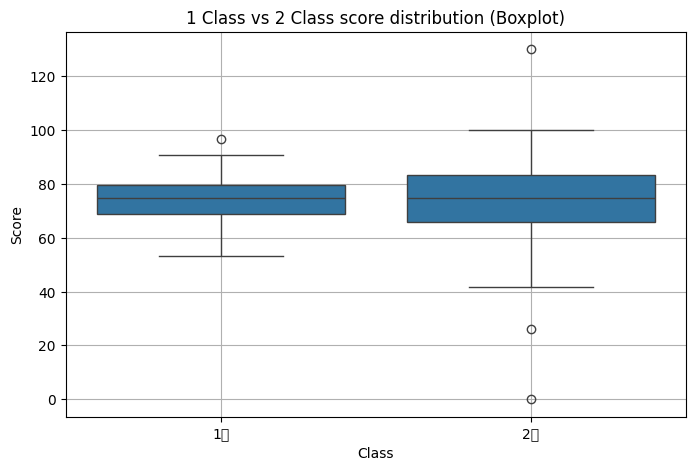

In [29]:
# 각 반별 데이터 추출
class1 = df3[df3['class'] == '1반']['score']
class2 = df3[df3['class'] == '2반']['score']

# 통계값 계산
print("📊 [1반 통계]")
print(f"평균: {class1.mean():.2f}")
print(f"표준편차: {class1.std():.2f}")
print(f"최소값: {class1.min():.2f}, 최대값: {class1.max():.2f}")
print()

print("📊 [2반 통계]")
print(f"평균: {class2.mean():.2f}")
print(f"표준편차: {class2.std():.2f}")
print(f"최소값: {class2.min():.2f}, 최대값: {class2.max():.2f}")

# 박스플롯 시각화
plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='score', data=df3)
plt.title("1 Class vs 2 Class score distribution (Boxplot)")
plt.xlabel("Class")
plt.ylabel("Score")
plt.grid(True)
plt.show()

**데이터 요약 결과**
1. 2반의 분산이 1반보다 크다
    - 분산, 표준편차, 범위 등 **퍼짐 정도**를 확인 할 수 있는 지표들이 있다
    - 이상값이 포함되면 표준편차나 범위는 매우 커진다 (특히 범위가 제일 커짐)

2. 평균은 모든 데이터 값을 더해 개수로 나누기 때문에 **이상치에 매우 민감**
    - 극단적으로 낮다면 평균이 내려가고, 극단적으로 높다면 평균이 오른다
    - **중앙값**은 데이터 정렬 시 무조건 중앙에 위치한 값이므로 이상값의 영향을 받지 않는다
    - **평균과 중앙값의 차이**가 크다면, 그 데이터 분포에 이상치가 존재하거나 어느 한쪽으로 치우쳐 있음을 의미한다

3. 박스플롯 -> **최솟값, Q1, 중앙값, Q3, 최댓값**을 시각화한다
    - 박스플롯 바깥으로 벗어난 점이 **이상치**이다
    - 1반의 경우 상대적으로 박스의 높이(**IQR**)가 좁고 짧지만, 2반의 경우 박스 자체도 더 길고 바깥으로 이상치가 존재해 분포가 훨씬 **불안정**함

4. 평균만 보고 평가한다면, 집단 내부의 분포를 보여주지 못한다
    - 2반이 1반보다 실력이 부족하다고 판단하면, **이상치(0점)**으로 인해 실력이 과소평가됨
    - 따라서 **중앙값**을 통해 실제 중간 수준을 확인하고, **표준편차**를 통해 집단 내 편차가 심한지 함께 분석해야 한다

# 정규분포와 표준편차

- 정규분포와 표준편차의 개념을 실제 데이터에 적용
- 정규분포를 따르는 점수 데이터에서 다음을 확인
  - 평균 ±1σ, 평균 ±2σ 범위에 속한 값들의 비율은 실제로 얼마인지,
  - 이 결과가 이론적인 68-95-99 법칙과 얼마나 유사한지 비교

<br>

1. 평균이 70, 표준편차가 10인 정규분포 데이터를 1000개 생성
2. 평균을 중심으로 ±1σ, ±2σ 범위에 포함되는 데이터의 비율을 계산
3. 결과를 바탕으로 68-95-99 법칙과 비교


In [31]:
# 데이터 생성
np.random.seed(2025)
data = np.random.normal(loc=70, scale=10, size=1000)

# 평균과 표준편차
mean = np.mean(data)
std = np.std(data)

# 비율 계산
within_1 = np.mean((data >= mean - std) & (data <= mean + std))
within_2 = np.mean((data >= mean - 2*std) & (data <= mean + 2*std))

print(f"±1σ 범위 비율: {within_1:.2%}")
print(f"±2σ 범위 비율: {within_2:.2%}")

±1σ 범위 비율: 68.70%
±2σ 범위 비율: 95.00%


- ±1σ: 약 **68%**, ±2σ: 약 **95%**의 데이터가 포함
- 이는 실제 데이터도 **정규분포의 특징**을 잘 따르고 있다는 의미

- 이론적으로 정규분포 데이터는 다음과 같은 비율을 가짐
  - ±1σ: 약 **68.27%**
  - ±2σ: 약 **95.45%**
  - ±3σ: 약 **99.73%**
  - 실측 결과가 이와 유사하다면 → 정규분포 가정이 타당함
  > [참고] 이 법칙이 "정규분포의 3σ 법칙"

- 표준편차는 데이터가 **평균을 기준으로 얼마나 흩어져 있는지**를 표현
- 작을수록 데이터가 평균 근처에 몰리고, 클수록 퍼져 있는 분포
- 정규분포에서는 표준편차만 알면 전체 분포의 **형태와 확률 예측**이 가능

- 해당 예시는 시험 점수, IQ, 제품 품질 관리, 금융 리스크 분석 등에서 자주 사용
- 예: "이 제품은 평균 ±2σ 범위 안에 들어야 합격입니다."
  > [예시] 불량률 5% 이하를 목표로 할 때, ±2σ 기준을 사용하는 경우가 많습니다.


# 로또 번호의 평균으로 정규분포 만들기

- 중심극한정리를 시각화 해보았음

In [32]:
import random
def generate_lotto_numbers():
    min_num = 1
    max_num = 45
    num_picks = 6


    possible_numbers = list(range(min_num, max_num + 1))
    lotto_numbers = random.sample(possible_numbers, num_picks)
    # Sort the numbers for better readability (optional)
    lotto_numbers.sort()

    return lotto_numbers

In [33]:
num_simulations = 10000

all_lotto_numbers = []
lotto_means = []

for _ in range(num_simulations):
    current_lotto_draw = generate_lotto_numbers()
    all_lotto_numbers.extend(current_lotto_draw)
    lotto_means.append(np.mean(current_lotto_draw))

print(f"Completed {num_simulations} Lotto simulations.")
print(f"Total individual numbers collected: {len(all_lotto_numbers)}")
print(f"Total means collected: {len(lotto_means)}")

Completed 10000 Lotto simulations.
Total individual numbers collected: 60000
Total means collected: 10000


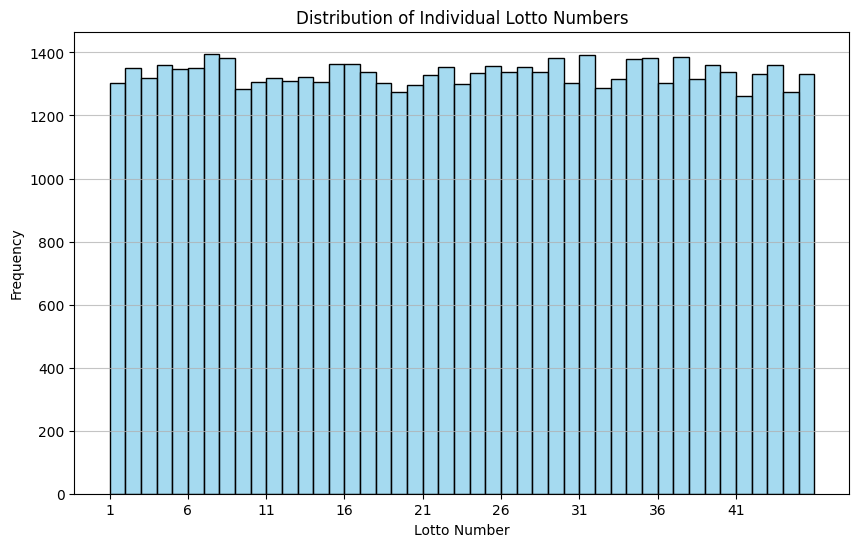

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(all_lotto_numbers, bins=range(1, 45 + 2), kde=False, color='skyblue')
plt.title('Distribution of Individual Lotto Numbers')
plt.xlabel('Lotto Number')
plt.ylabel('Frequency')
plt.xticks(range(1, 45 + 1, 5))
plt.grid(axis='y', alpha=0.75)
plt.show()

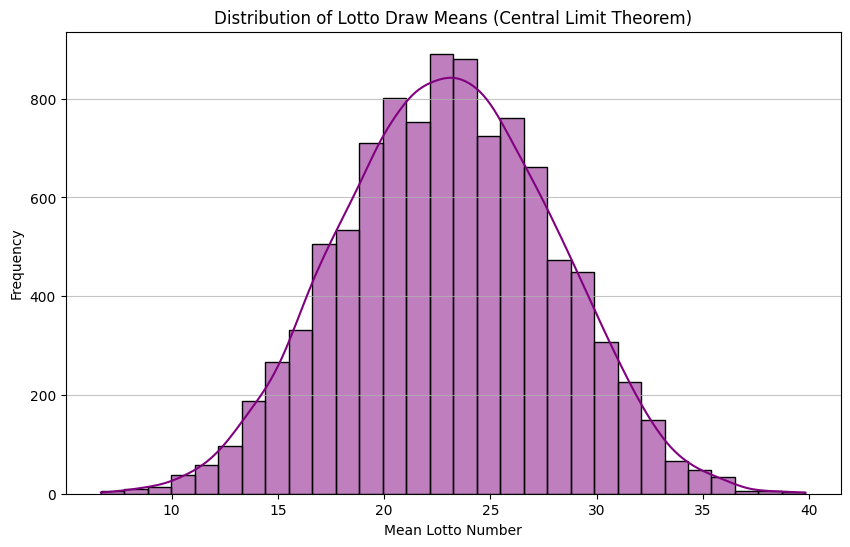

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(lotto_means, kde=True, color='purple', bins=30)
plt.title('Distribution of Lotto Draw Means (Central Limit Theorem)')
plt.xlabel('Mean Lotto Number')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 신뢰구간 계산과 해석


- 표본 평균은 모집단 평균을 추정하는 좋은 **점 추정** 값이지만, 표본오차 때문에 정확히 일치하지는 않음

- 그래서 우리는 "모집단 평균이 아마 이 범위 안에 있을 것이다"라고 **구간추정**하는 것이 더 합리적
- 이때 사용하는 개념이 바로 **신뢰구간**!

- 신뢰구간은 표본평균 ± 오차범위 형태로 계산되며, 이 오차범위는 신뢰수준(예: 95%, 99%)과 표본오차에 의해 결정

- **모집단 표준편차(σ)를 알 때(z-분포)**와 **모를 때(t-분포)**의 신뢰구간을 각각 계산해보고, 신뢰수준에 따라 구간의 폭이 어떻게 변하는지 확인


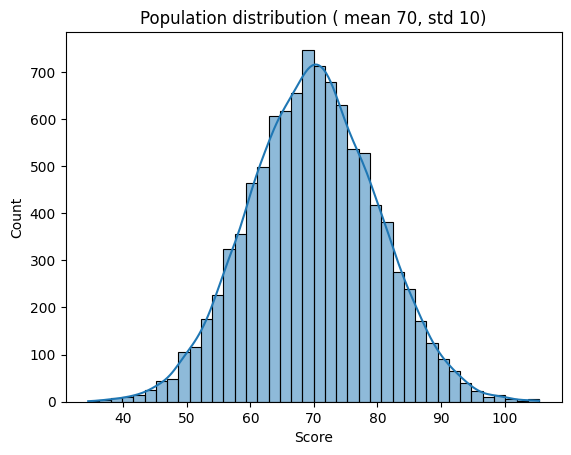

In [38]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("Population distribution ( mean 70, std 10)")
plt.xlabel("Score")
plt.show()

In [39]:
# Q1. 표본 30명을 무작위로 추출하고, 표본 평균, 표준편차, 표준오차 계산

sample = np.random.choice(population, size=30)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)  # 표본 표준편차 (ddof=1)
se = sample_std / np.sqrt(30)        # 표준오차

print(f"표본 평균: {sample_mean:.2f}")
print(f"표본 표준편차: {sample_std:.2f}")
print(f"표준오차(SE): {se:.2f}")

표본 평균: 71.52
표본 표준편차: 9.34
표준오차(SE): 1.70


In [40]:
# 모집단 표준편차를 알고 있다고 가정하고, z-분포로 95% 신뢰구간 계산

sigma = 15  # 모집단 표준편차를 알고 있다고 가정
z = 1.96    # 95% 신뢰수준에서의 z값

ci_low = sample_mean - z * (sigma / np.sqrt(30))
ci_high = sample_mean + z * (sigma / np.sqrt(30))

print(f"[z-분포 기반] 95% 신뢰구간: ({ci_low:.2f}, {ci_high:.2f})")

[z-분포 기반] 95% 신뢰구간: (66.15, 76.88)


In [41]:
# Q3. 모집단 표준편차를 모른다고 가정하고, t-분포로 95% 신뢰구간 계산

from scipy import stats

t = stats.t.ppf(0.975, df=29)  # df = n - 1 = 29
ci_low_t = sample_mean - t * se
ci_high_t = sample_mean + t * se

print(f"[t-분포 기반] 95% 신뢰구간: ({ci_low_t:.2f}, {ci_high_t:.2f})")

[t-분포 기반] 95% 신뢰구간: (68.03, 75.00)


In [42]:
# 신뢰수준을 90%, 99%로 바꿔가며 t-분포 기반 신뢰구간 계산

# 90%
t_90 = stats.t.ppf(0.95, df=29)  # 양쪽 각각 5%
ci90 = (sample_mean - t_90 * se, sample_mean + t_90 * se)

# 99%
t_99 = stats.t.ppf(0.995, df=29)  # 양쪽 각각 0.5%
ci99 = (sample_mean - t_99 * se, sample_mean + t_99 * se)

print(f"[t-분포 기반] 90% 신뢰구간: ({ci90[0]:.2f}, {ci90[1]:.2f})")
print(f"[t-분포 기반] 99% 신뢰구간: ({ci99[0]:.2f}, {ci99[1]:.2f})")

[t-분포 기반] 90% 신뢰구간: (68.62, 74.41)
[t-분포 기반] 99% 신뢰구간: (66.82, 76.22)


- 일반적으로 **$t$-분포**를 사용한 신뢰구간이 **$z$-분포**보다 약간 더 넓게 나타남
    - $t$-분포는 모집단의 표준편차를 모르는 상태에서 표본의 표준편차를 사용하므로, 그만큼의 **불확실성을 더 반영**하기 때문 (그래서 구간을 러프하게 잡음)
    - **표본 크기($n$)가 클수록** 두 분포의 차이는 줄어들지만, 지금처럼 표본이 작을 경 **$t$-분포가 더 안전한 예측**을 제공

- 신뢰수준이 높아질수록(예: 95% → 99%) 신뢰구간의 폭은 **더 넓어짐**
    - 신뢰수준이 높다는 것은 **"이 구간 안에 모평균이 있을 것이라고 확신하는 정도"가 커야 한다**는 뜻
    - 더욱 확신을 가지려면 **구간을 훨씬 러프하게 잡아야 하기 때문**
    - 따라서 신뢰수준이 높아질수록 **임계값($z$값이나 $t$값)이 커지기 때문에 오차 범위가 늘어남**

- 신뢰구간이 넓다는 건 정보의 가치 측면에서는 **좋지 않음**
    - 신뢰구간이 넓다는 것은 우리가 추정한 값이 **정확도가 낮음**을 의미
    - 주로 표본의 크기가 너무 작거나, 데이터 자체의 변동성(분산)이 매우 클 때 그러함
    - 신뢰구간을 좁히기 위해서는(=정밀도를 높이기 위해) **표본의 수를 늘리는 것**이 권장

- 예를 들어, "고객 만족도 평균이 68~72점 사이"라는 신뢰구간이 있다면, 
- 마케팅측면에서는 이 범위를 근거로 다음을 활용할 수 있다
  - **신규 제품 만족도 타겟 설정**
  - **고객 충성도 유지 기준 수립**
  - **점수 변동이 통계적으로 유의한지 판단**    
  > 신뢰구간은 단순한 평균보다 **전략적 의사결정에 더 강력한 근거**가 됩니다.
